# 1. Imports and Data load
<a id="1"></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_colwidth', None)

from sklearn.decomposition import TruncatedSVD

from warnings import simplefilter
simplefilter("ignore")

In [2]:
ratings_df_no_0 = pd.read_csv('../data/ratings_transformed.csv')
books_df = pd.read_csv('../data/books_transformed.csv')

# 2. New Dataframe: Ratings by Author
<a id="2"></a>

I am creating a new dataframe by merging the previous dataframes.

In [3]:
book_ratings = pd.merge(ratings_df_no_0, books_df, on='ISBN')

book_ratings.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle
1,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press
2,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge English Readers),Sue Leather,2001,Cambridge University Press
3,276744,038550120X,7,A Painted House,JOHN GRISHAM,2001,Doubleday
4,276747,0060517794,9,Little Altars Everywhere,Rebecca Wells,2003,HarperTorch


It is clear that there are multiple editions of the books, maybe even several different translations.

This is why I prefer to extract a new dataframe by grouping the authors and calculating their scores averaged over their books.

In [4]:
author_ratings = book_ratings.groupby(['User-ID', 'Book-Author'])['Book-Rating'].mean().reset_index(name='Avg Rating')

author_ratings.head()

,User-ID,Book-Author,Avg Rating
0,8,Ann Beattie,5.0
1,8,Julia Oliver,7.0
2,8,Loren D. Estleman,6.0
3,8,R. J. Kaiser,5.0
4,8,Richard Bruce Wright,5.0


If I try to do the following steps on the full dataset, the kernel crashes because of the large amount of data to be processed.

To run the code successfully, I can either:
* Use big data tools, like Apache Spark.
* Reduce the dimension of the dataset by using only a fraction of it.

Here, I will follow the second strategy.

In [5]:
len(author_ratings)

322135

I will only keep the authors that are in the top 500 authors' list.

In [6]:
author_count = books_df['Book-Author'].value_counts().reset_index(name='Count').sort_values('Count', ascending=False).head(500)

author_count.tail()

top_500_authors = author_count[author_count['Book-Author'] != 'Not Applicable (Na )']['Book-Author'].to_list()

len(top_500_authors)

499

In [7]:
reduced_author_ratings = author_ratings[author_ratings['Book-Author'].isin(top_500_authors)]

len(reduced_author_ratings)

74777

The dataframe is still big. Thus, I will further cut its dimension.

In [8]:
reduced_author_ratings = reduced_author_ratings.iloc[0:5000]

print(len(reduced_author_ratings))

reduced_author_ratings.head()

5000


,User-ID,Book-Author,Avg Rating
2,8,Loren D. Estleman,6.0
7,9,Toni Morrison,6.0
10,14,Mary-Kate &amp; Ashley Olsen,5.0
12,16,Michael Crichton,9.0
13,17,Agatha Christie,7.0


In [9]:
mean_rating = reduced_author_ratings['Avg Rating'].mean()

mean_rating

np.float64(7.523748647762592)

Finally, I need to pivot the data to get it into a user-item matrix format. I will also fill the null user ratings with 'mean_rating'.

In [10]:
X = reduced_author_ratings.pivot(index='User-ID', columns='Book-Author', values='Avg Rating').fillna(mean_rating)

print(X.shape)

X.head()

(1946, 477)


Book-Author,A. A. Milne,Agatha Christie,Alan Dean Foster,Albert Camus,Aldous Huxley,Alexandre Dumas,Alice Hoffman,Alice Walker,Alistair MacLean,Amy Tan,...,Walter Mosley,Warren Murphy,Whitley Strieber,Wilkie Collins,Willa Cather,William Faulkner,William Shakespeare,William Shatner,Wolfgang Hohlbein,Zane Grey
User-ID,,,,,,,,,,,,,,,,,,,,,
8,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,...,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749
9,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,...,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749
14,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,...,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749
16,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,...,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749
17,7.523749,7.000000,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,...,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749,7.523749


# 3. Book Author Recommender
<a id="4"></a>

## 3.1 Number of Truncated SVD Components

The first step is to center the data.

In [11]:
X_centered = X - X.mean()

X_centered.head()

Book-Author,A. A. Milne,Agatha Christie,Alan Dean Foster,Albert Camus,Aldous Huxley,Alexandre Dumas,Alice Hoffman,Alice Walker,Alistair MacLean,Amy Tan,...,Walter Mosley,Warren Murphy,Whitley Strieber,Wilkie Collins,Willa Cather,William Faulkner,William Shakespeare,William Shatner,Wolfgang Hohlbein,Zane Grey
User-ID,,,,,,,,,,,,,,,,,,,,,
8,-0.000489,-0.001106,0.000036,-0.004527,-0.005005,-0.000245,0.002682,-0.002778,0.001297,-0.005192,...,0.002422,0.000538,-0.000734,0.001089,-0.002447,0.001627,-0.008658,0.003866,0.00301,-0.000489
9,-0.000489,-0.001106,0.000036,-0.004527,-0.005005,-0.000245,0.002682,-0.002778,0.001297,-0.005192,...,0.002422,0.000538,-0.000734,0.001089,-0.002447,0.001627,-0.008658,0.003866,0.00301,-0.000489
14,-0.000489,-0.001106,0.000036,-0.004527,-0.005005,-0.000245,0.002682,-0.002778,0.001297,-0.005192,...,0.002422,0.000538,-0.000734,0.001089,-0.002447,0.001627,-0.008658,0.003866,0.00301,-0.000489
16,-0.000489,-0.001106,0.000036,-0.004527,-0.005005,-0.000245,0.002682,-0.002778,0.001297,-0.005192,...,0.002422,0.000538,-0.000734,0.001089,-0.002447,0.001627,-0.008658,0.003866,0.00301,-0.000489
17,-0.000489,-0.524854,0.000036,-0.004527,-0.005005,-0.000245,0.002682,-0.002778,0.001297,-0.005192,...,0.002422,0.000538,-0.000734,0.001089,-0.002447,0.001627,-0.008658,0.003866,0.00301,-0.000489


After centering the data, I will fit a truncated SVD model with all the columns.

In [12]:
svdAll = TruncatedSVD(n_components=X_centered.shape[1])

UAll = svdAll.fit_transform(X_centered)

Then, I will plot the cumulative explained variance ratios to find a cut-off value for the number of components.

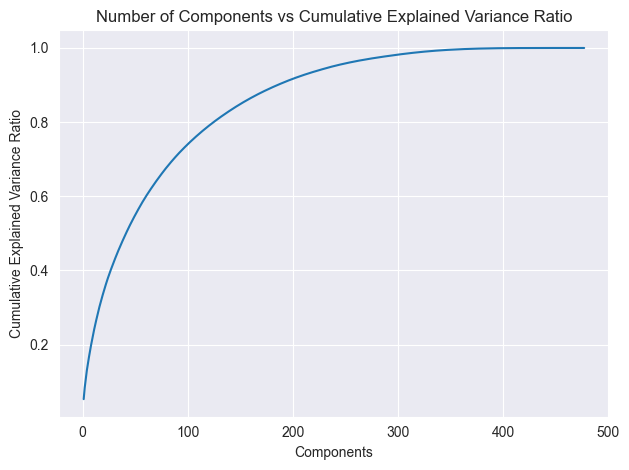

In [13]:
cum_evrAll = list(zip(range(1, UAll.shape[1] + 1), np.cumsum(svdAll.explained_variance_ratio_)))

cum_evrAll_df = pd.DataFrame(cum_evrAll).set_index(0)

cum_evrAll_df.plot(title='Number of Components vs Cumulative Explained Variance Ratio',
                xlabel='Components',
                ylabel='Cumulative Explained Variance Ratio',
                legend=False)

plt.tight_layout()

The plot shows that 200 components are enough to explain more than 80% of the cumulative explained variance ratio.

## 3.2 Update the model to 200 components

In [14]:
svd200 = TruncatedSVD(n_components=200)

U200 = svd200.fit_transform(X_centered)

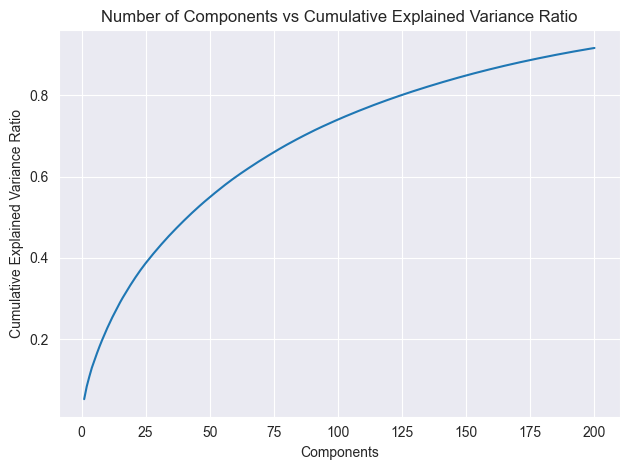

In [15]:
cum_evr200 = list(zip(range(1, U200.shape[1] + 1), np.cumsum(svd200.explained_variance_ratio_)))

cum_evr200_df = pd.DataFrame(cum_evr200).set_index(0)

cum_evr200_df.plot(title='Number of Components vs Cumulative Explained Variance Ratio',
                xlabel='Components',
                ylabel='Cumulative Explained Variance Ratio',
                legend=False)

plt.tight_layout()

## 3.3 Create a New User

I want to make recommendations for a new user.

First, I am creating a new user and I am filling its columns with NaNs.

In [16]:
vector_length = X_centered.shape[1]
new_user = np.full(vector_length, np.nan)

new_user_df = pd.DataFrame([new_user], columns=X_centered.columns)
new_user_df

new_user_df

Book-Author,A. A. Milne,Agatha Christie,Alan Dean Foster,Albert Camus,Aldous Huxley,Alexandre Dumas,Alice Hoffman,Alice Walker,Alistair MacLean,Amy Tan,...,Walter Mosley,Warren Murphy,Whitley Strieber,Wilkie Collins,Willa Cather,William Faulkner,William Shakespeare,William Shatner,Wolfgang Hohlbein,Zane Grey
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Then, I am assigning different values to a few of these cells. These would be the ratings by the new user.

In [17]:
new_user_df['Albert Camus'] = 8
new_user_df['Agatha Christie'] = 5
new_user_df['William Shakespeare'] = 9
new_user_df['Franz Kafka'] = 10
new_user_df['Walt Disney Productions'] = 4
new_user_df['Italo Calvino'] = 8

new_user_df

Book-Author,A. A. Milne,Agatha Christie,Alan Dean Foster,Albert Camus,Aldous Huxley,Alexandre Dumas,Alice Hoffman,Alice Walker,Alistair MacLean,Amy Tan,...,Walter Mosley,Warren Murphy,Whitley Strieber,Wilkie Collins,Willa Cather,William Faulkner,William Shakespeare,William Shatner,Wolfgang Hohlbein,Zane Grey
0,NaN,5,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,9,NaN,NaN,NaN


As a check, I can view only the authors rated by the user.

In [18]:
new_user_df.T.dropna()

,0
Book-Author,
Agatha Christie,5.0
Albert Camus,8.0
Franz Kafka,10.0
Italo Calvino,8.0
Walt Disney Productions,4.0
William Shakespeare,9.0


## 3.4 Create Recommendations for the New User

First of all, I have to fill the NaN values in the new user's columns. Then, I am centering the data.

In [19]:
new_user_fillna_df = new_user_df.fillna(mean_rating)

# center the data
new_user_centered_df = new_user_fillna_df - X.mean()

new_user_centered_df

Book-Author,A. A. Milne,Agatha Christie,Alan Dean Foster,Albert Camus,Aldous Huxley,Alexandre Dumas,Alice Hoffman,Alice Walker,Alistair MacLean,Amy Tan,...,Walter Mosley,Warren Murphy,Whitley Strieber,Wilkie Collins,Willa Cather,William Faulkner,William Shakespeare,William Shatner,Wolfgang Hohlbein,Zane Grey
0,-0.000489,-2.524854,0.000036,0.471724,-0.005005,-0.000245,0.002682,-0.002778,0.001297,-0.005192,...,0.002422,0.000538,-0.000734,0.001089,-0.002447,0.001627,1.467593,0.003866,0.00301,-0.000489


Then, I am transforming the user into the latent space.

In [20]:
new_user_200d = svd200.transform(new_user_centered_df)

print(new_user_200d.shape)

new_user_200d

(1, 200)


array([[-0.03558631,  0.03399825, -0.14935937,  0.06590714, -0.2131917 ,
         0.09571036, -0.09214572,  0.32466184,  0.34091421, -0.04291957,
         0.28783683,  0.09930283, -0.1287067 ,  0.05207935,  0.00159988,
        -0.01203432,  0.07787001, -0.00434822,  0.2347381 , -0.29279934,
         0.48861487, -0.02212443, -0.04086571,  0.00701226, -0.12095343,
         0.7953194 , -0.45650142, -0.31254557,  0.27016834,  0.19822037,
        -0.47889839, -0.24341788,  0.31975092, -0.32499573, -0.21770354,
        -0.15994683, -0.04407524, -0.0470057 , -0.08328296,  0.12297231,
        -0.0868976 ,  0.00146402, -0.0176624 , -0.0056064 ,  0.00974435,
         0.1254624 , -0.00361224, -0.03323167, -0.36389572,  0.24504631,
         0.12276225, -0.06896654,  0.0960761 ,  0.02287884, -0.0946978 ,
         0.02321304, -0.25908974,  0.14746439,  0.11165581,  0.23519525,
         0.03542086,  0.10108291, -0.08323238, -0.05659812, -0.02110991,
         0.16803073,  0.15411388,  0.418859  ,  0.1

I am reconstructing the user-item matrix for the new user.

In [21]:
new_user_pred = np.dot(new_user_200d, svd200.components_)

new_user_pred

array([[-1.84737302e-02, -2.41286038e+00, -1.76616348e-02,
         1.46297028e-01,  4.77233612e-02, -1.74693085e-03,
         2.29275399e-02,  5.04302421e-04,  1.96555138e-02,
         1.36781428e-02,  1.96888157e-02, -9.17813727e-04,
         2.82961184e-02,  2.36198202e-02, -2.83324779e-02,
        -5.54657263e-02, -3.08790096e-03, -2.07651706e-02,
        -1.37719668e-01,  9.44536392e-03,  2.85036505e-02,
        -3.81891752e-03,  8.53243763e-03, -1.00878296e-03,
         5.32024652e-03,  2.27924815e-02, -4.18937983e-02,
        -2.57624708e-02, -2.07890518e-02, -3.35559817e-04,
        -3.02719264e-02,  4.50976570e-02,  2.52424206e-02,
        -3.79252255e-03,  4.75453105e-03, -3.09796961e-02,
         2.49675051e-03, -1.81210593e-02,  1.69225675e-03,
         1.77282112e-01, -2.73682915e-02, -1.92105439e-01,
        -1.85498626e-02, -8.66959735e-03,  3.49534763e-03,
        -1.28392706e-02,  9.80800533e-04, -2.32941604e-03,
        -3.51197044e-02,  2.80324855e-02, -1.15838175e-0

I am making recommendation for the new user and then I am sorting them.

In [22]:
new_user_recs = pd.DataFrame(new_user_pred, columns=X.columns)

top_recs = new_user_recs.T.sort_values(by=0, ascending=False)
top_recs.columns = ['Predicted_Rating']
top_recs.reset_index(inplace=True)
top_recs.head()

,Book-Author,Predicted_Rating
0,Franz Kafka,2.361436
1,William Shakespeare,1.432900
2,Barbara Park,0.177282
3,Joan Lowery Nixon,0.174814
4,Gertrude Chandler Warner,0.153863


To get a more useful output, I am excluding the book authors that the user had already recommended himself.

In [23]:
already_rated = new_user_df.T.dropna().index

top_recs_final = top_recs[~top_recs['Book-Author'].isin(already_rated)]
top_recs_final.head(10)

,Book-Author,Predicted_Rating
2,Barbara Park,0.177282
3,Joan Lowery Nixon,0.174814
4,Gertrude Chandler Warner,0.153863
5,Pablo Neruda,0.152175
6,Henry James,0.151278
8,Elizabeth George,0.140341
9,Eve Bunting,0.139055
10,Laura Ingalls Wilder,0.134618
11,James Ellroy,0.114150
12,Max Lucado,0.111912


# References

* Alice Zhao (Maven Analytics), Python Data Science: Unsupervised Machine Learning, course on Udemy.